# Quickstart — robust regression in 5 minutes

**Audience:** you have a dataset, you want to fit a regression, and you suspect a handful of outliers is wrecking your OLS estimate. You want a one-line robust alternative that drops in next to `statsmodels.OLS` and gives sensible coefficients.

**The story:** the `mineral` dataset from Maronna et al. (2019) measures zinc content of pine needles vs the soil's copper content. One outlier (a sample taken right next to a copper mine) is dominating the OLS slope. We'll fix that.

By the end of this notebook you will have used:
- `rpm.lmrobdet_mm` — robust MM-regression
- `fit.summary()` — coefficient table
- `fit.predict(new_df)` — predictions on new data
- `fit.plot_diagnostics()` — 4-panel diagnostic plot

In [1]:
# (Windows only — point rpy2 at the R install.  Skip on Linux/Mac.)
import os, sys
if sys.platform == 'win32' and 'R_HOME' not in os.environ:
    os.environ['R_HOME'] = r'C:\Program Files\R\R-4.5.2'
    os.environ['PATH']   = r'C:\Program Files\R\R-4.5.2\bin\x64;' + os.environ['PATH']

import numpy as np
import pandas as pd
import robstatm_py as rpm

## Step 1 — load the data

Every textbook dataset is shipped with the package. They return as pandas DataFrames with R column names preserved.

In [2]:
df = rpm.datasets.mineral()
print(f'shape: {df.shape}')
df.head()

shape: (53, 2)


,copper,zinc
1,102.0,4.0
2,96.0,56.0
3,265.0,2.0
4,185.0,8.0
5,229.0,26.0


## Step 2 — quick look at the data

We expect zinc to rise with copper (both are heavy metals leaching from the same soil). A scatter plot reveals one obvious outlier at the high-copper end:

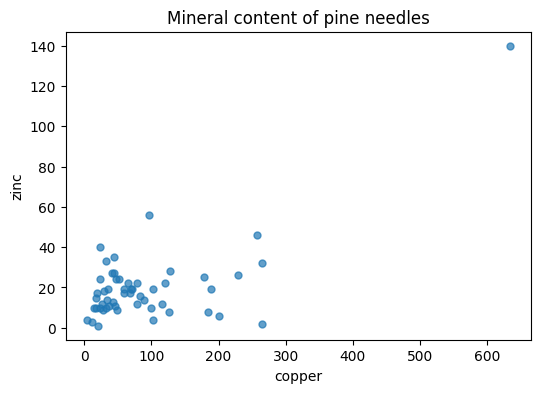

In [3]:
import matplotlib.pyplot as plt
fig, ax = plt.subplots(figsize=(6, 4))
ax.scatter(df['copper'], df['zinc'], s=25, alpha=0.7)
ax.set(xlabel='copper', ylabel='zinc', title='Mineral content of pine needles')
plt.show()

## Step 3 — compare OLS vs robust MM

OLS is sensitive to the outlier; the robust MM estimator downweights it. We'll fit both and look at the slope.

In [4]:
from numpy.polynomial import polynomial as P

# Classical OLS via numpy
b_ols = np.linalg.lstsq(
    np.column_stack([np.ones(len(df)), df['copper']]),
    df['zinc'].to_numpy(),
    rcond=None
)[0]

# Robust MM via robstatm_py — one line
fit = rpm.lmrobdet_mm('zinc ~ copper', data=df)

print(f'  OLS slope:    {b_ols[1]:.5f}')
print(f'  Robust slope: {fit.coefficients[1]:.5f}')
print(f'  Ratio:        {b_ols[1] / fit.coefficients[1]:.2f}x  (OLS overshoots)')

R callback write-console: Registered S3 method overwritten by 'robustbase':
  method          from     
  hatvalues.lmrob RobStatTM
  


  OLS slope:    0.13457
  Robust slope: 0.01256
  Ratio:        10.71x  (OLS overshoots)


OLS slope is **~10x** the robust slope — the outlier alone is pulling OLS that much. Let's overlay both fits:

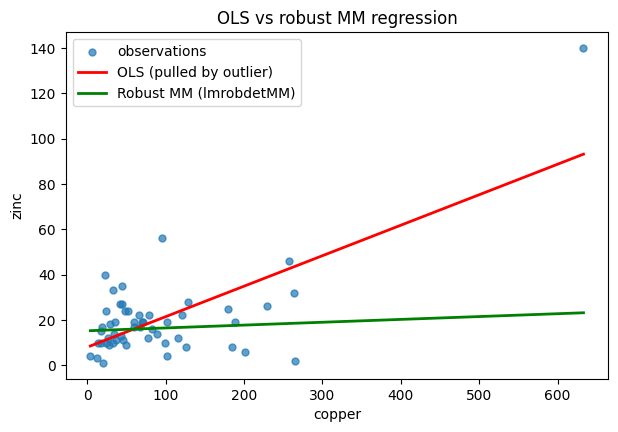

In [5]:
fig, ax = plt.subplots(figsize=(7, 4.5))
ax.scatter(df['copper'], df['zinc'], s=25, alpha=0.7, label='observations')
xs = np.linspace(df['copper'].min(), df['copper'].max(), 100)
ax.plot(xs, b_ols[0] + b_ols[1]*xs, 'r-',  lw=2, label='OLS (pulled by outlier)')
ax.plot(xs, fit.coefficients[0] + fit.coefficients[1]*xs, 'g-', lw=2, label='Robust MM (lmrobdetMM)')
ax.set(xlabel='copper', ylabel='zinc', title='OLS vs robust MM regression')
ax.legend()
plt.show()

## Step 4 — interpret the fit

Just like `summary(lm(...))` in R or `model.summary()` in statsmodels, every fit has a `.summary()` method:

In [6]:
print(fit.summary())

Call: lmrobdetMM-family(zinc ~ copper)

Coefficients:
             Estimate  Std. Error  t value   Pr(>|t|)
(Intercept)    15.201      2.2532   6.7465 1.3686e-08
copper       0.012561    0.022269  0.56408    0.57517

Robust residual standard error: 9.997
Multiple R-squared: 0.008201, Adjusted R-squared: -0.01125
Convergence in 17 IRWLS iterations


The coefficient table is a real pandas DataFrame — easy to pipe into reporting code:

In [7]:
fit.summary().coefficients_table

,Estimate,Std. Error,t value,Pr(>|t|)
(Intercept),15.201217,2.253191,6.746528,1.368631e-08
copper,0.012561,0.022269,0.564082,5.751705e-01


## Step 5 — predict on new data

`fit.predict()` takes a pandas DataFrame with the same column names as the formula. Just like statsmodels:

In [8]:
new_df = pd.DataFrame({'copper': [10, 50, 100, 200, 500]})
new_df['zinc_predicted'] = fit.predict(new_df)
new_df

,copper,zinc_predicted
0,10,15.326832
1,50,15.829292
2,100,16.457367
3,200,17.713517
4,500,21.481965


## Step 6 — diagnostic plots

`fit.plot_diagnostics()` produces the 2×2 panel you'd get from `plot(lm(...))` in R — residuals vs fitted, Q-Q, scale-location, and a **robust-weights** panel showing which observations were downweighted.

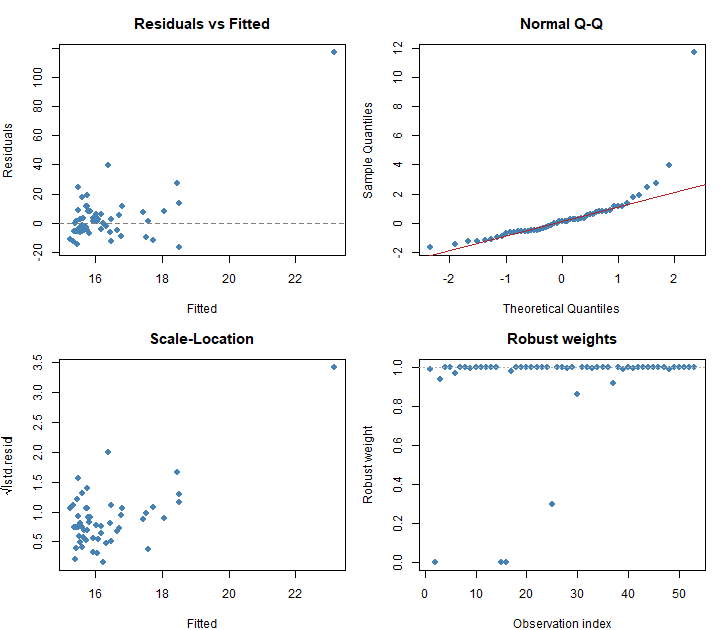

In [9]:
from robstatm_py.plotting import show_png
png = fit.plot_diagnostics(path='quickstart_diag.png', dpi=90, width=8, height=7)
show_png(png)

Notice the bottom-right panel — one observation has robust weight near 0. That's the outlier. The fit handled it silently and gave us a coefficient we can trust.

## Wrap-up

That's everything a 5-minute workflow needs:

```python
import robstatm_py as rpm
df  = rpm.datasets.mineral()
fit = rpm.lmrobdet_mm('zinc ~ copper', data=df)
print(fit.summary())
fit.predict(new_df)
fit.plot_diagnostics()
```

Next: try the same workflow on your own data. The only thing that needs to change is the formula and the DataFrame.